In [1]:
import os
os.environ['KAGGLE_USERNAME']='mohamedfaheem123'
os.environ['KAGGLE_KEY']='KGAT_def3f224d8ab37aeeeef3311190d61b4'

In [2]:
pip install kaggle

In [3]:
!kaggle datasets download -d "shrutimehta/zomato-restaurants-data"

Dataset URL: https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data
License(s): CC0-1.0
100% 5.47M/5.47M [00:00<00:00, 39.6MB/s]



In [4]:
!unzip zomato-restaurants-data.zip

Archive:  zomato-restaurants-data.zip
  inflating: Country-Code.xlsx       
  inflating: file1.json              
  inflating: file2.json              
  inflating: file3.json              
  inflating: file4.json              
  inflating: file5.json              
  inflating: zomato.csv              


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error

In [6]:
df = pd.read_csv('zomato.csv', encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [7]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,ÛÁstanbul,"CafeaÛôa Mahallesi, BademaltÛ± Sokak, No 21/B,...",Moda,"Moda, ÛÁstanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [9]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [10]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [11]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [12]:
df["Cuisines"].fillna(df["Cuisines"].mode()[0],inplace=True)
df.isnull().sum()

/tmp/ipykernel_570/3058316339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cuisines"].fillna(df["Cuisines"].mode()[0],inplace=True)


,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


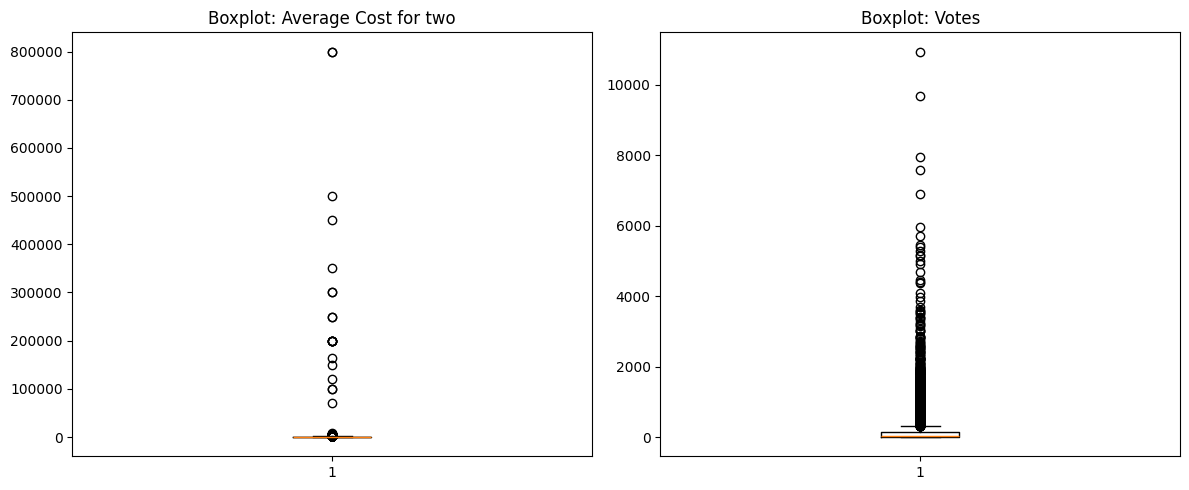

In [13]:
numeric_cols = ["Average Cost for two", "Votes"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col], vert=True)
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("outlier_boxplots_before.png", dpi=150)
plt.show()

In [14]:
print(df[numeric_cols].describe())


       Average Cost for two         Votes
count           9551.000000   9551.000000
mean            1199.210763    156.909748
std            16121.183073    430.169145
min                0.000000      0.000000
25%              250.000000      5.000000
50%              400.000000     31.000000
75%              700.000000    131.000000
max           800000.000000  10934.000000


In [15]:
def cap_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    n_outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    print(f"{column}: capping {n_outliers} outliers "
          f"(bounds: {lower_bound:.2f} to {upper_bound:.2f})")


In [16]:
def cap_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    n_outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    print(f"{column}: capping {n_outliers} outliers "
          f"(bounds: {lower_bound:.2f} to {upper_bound:.2f})")
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

for col in numeric_cols:
    df = cap_outliers_iqr(df, col)

Average Cost for two: capping 853 outliers (bounds: -425.00 to 1375.00)
Votes: capping 1126 outliers (bounds: -184.00 to 320.00)


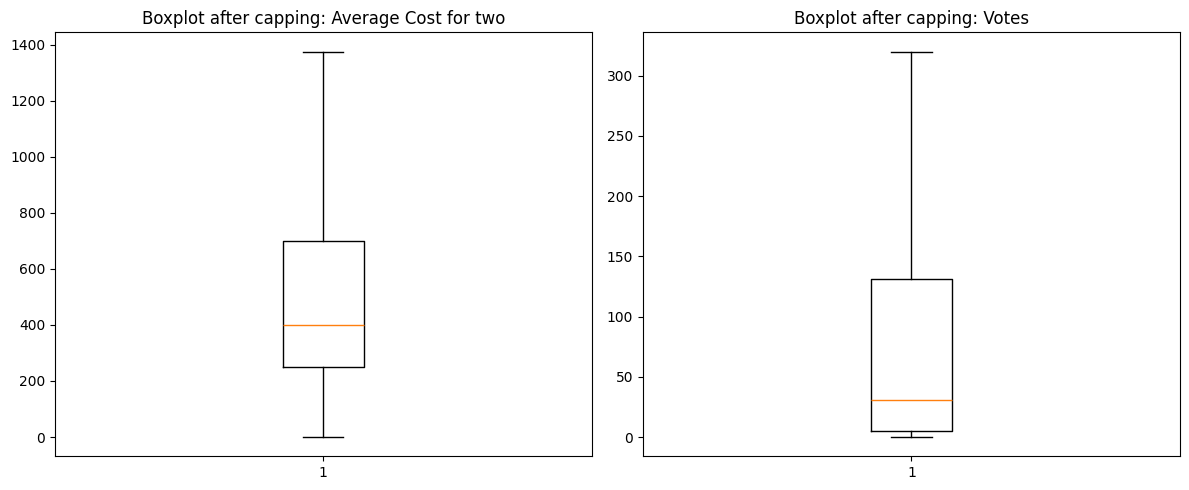


Done. Outliers capped using IQR method (factor=1.5).


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col], vert=True)
    ax.set_title(f"Boxplot after capping: {col}")
plt.tight_layout()
plt.savefig("outlier_boxplots_after.png", dpi=150)
plt.show()

print("\nDone. Outliers capped using IQR method (factor=1.5).")

In [18]:
df['Cost_per_person'] = df['Average Cost for two'] / 2

In [19]:
df['Rating_Category'] = pd.cut(
    df['Aggregate rating'],
    bins=[0, 2.5, 3.5, 4.5, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)

In [20]:
df.drop(["Restaurant ID"],axis=1,inplace=True)

In [21]:
df.head()

,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,...,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cost_per_person,Rating_Category
0,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,...,No,No,No,3,4.8,Dark Green,Excellent,314,550.0,Excellent
1,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,...,No,No,No,3,4.5,Dark Green,Excellent,320,600.0,Good
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",1375,...,No,No,No,4,4.4,Green,Very Good,270,687.5,Good
3,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1375,...,No,No,No,4,4.9,Dark Green,Excellent,320,687.5,Excellent
4,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1375,...,No,No,No,4,4.8,Dark Green,Excellent,229,687.5,Excellent


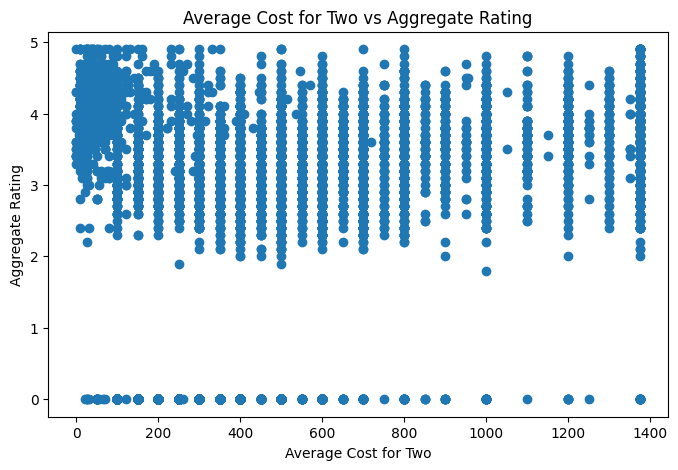

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['Average Cost for two'], df['Aggregate rating'])
plt.title('Average Cost for Two vs Aggregate Rating')
plt.xlabel('Average Cost for Two')
plt.ylabel('Aggregate Rating')
plt.show()

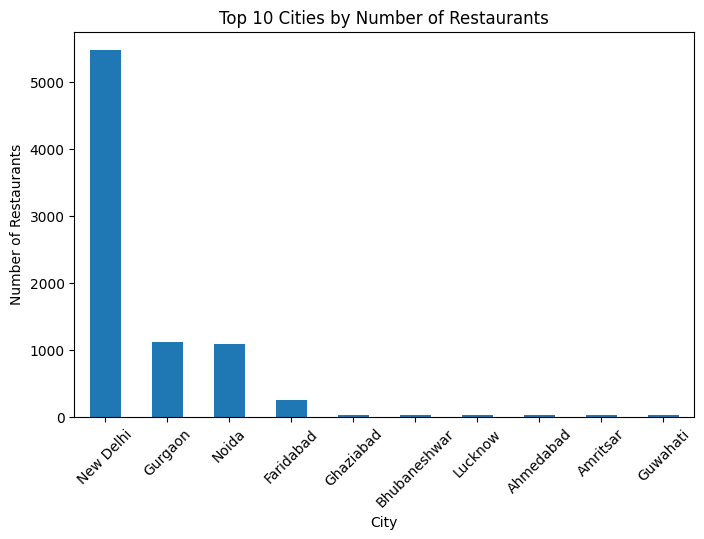

In [23]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_cities.plot(kind='bar')
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [25]:
df['Rating_Category'] = le.fit_transform(df['Rating_Category'])
df.head()

,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,...,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cost_per_person,Rating_Category
0,3749,162,73,8685,171,172,121.027535,14.565443,920,1100,...,0,0,0,3,4.8,0,1,314,550.0,1
1,3173,162,73,6055,593,601,121.014101,14.553708,1111,1200,...,0,0,0,3,4.5,0,1,320,600.0,2
2,2897,162,75,4684,308,314,121.056831,14.581404,1671,1375,...,0,0,0,4,4.4,1,5,270,687.5,2
3,4707,162,75,8690,862,875,121.056475,14.585318,1126,1375,...,0,0,0,4,4.9,0,1,320,687.5,1
4,5523,162,75,8689,862,875,121.057508,14.584450,1122,1375,...,0,0,0,4,4.8,0,1,229,687.5,1


In [26]:
x=df.drop(['Restaurant Name','Address','Locality Verbose','Aggregate rating','Rating color','Rating text','Rating_Category'],
axis=1)
y=df['Aggregate rating']

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
rf_model = RandomForestRegressor(n_estimators=500,max_depth=3,
min_samples_leaf=1,random_state=42)
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=3, n_estimators=500, random_state=42)

In [35]:
rf_preds = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, rf_preds)
print("rf_mse:",rf_mse)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print("rf_rmse:",rf_rmse)
rf_mae = mean_absolute_error(y_test, rf_preds)
print("rf_mae:",rf_mae)
rf_r2 = r2_score(y_test, rf_preds)
print("rf_r2:",rf_r2)



rf_mse: 0.1261462655795338
rf_rmse: 0.3551707555240631
rf_mae: 0.23207582961117967
rf_r2: 0.9445781084664221


In [36]:
train_score = rf_model.score(x_train, y_train)
print("Train_Score:",train_score)
test_score= rf_model.score(x_test, y_test)
print("test_Score:",test_score)

Train_Score: 0.9438258505768116
test_Score: 0.9445781084664221


In [43]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)
gb_model.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, n_estimators=200, random_state=42)

In [44]:
gb_preds = gb_model.predict(x_test)
gb_mse = mean_squared_error(y_test, gb_preds)
print("gb_mse",gb_mse)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
print("gb_rmse",gb_rmse)
gb_mae = mean_absolute_error(y_test, gb_preds)
print("gb_mae",gb_mae)
gb_r2 = r2_score(y_test, gb_preds)
print("gb_r2",gb_r2)

gb_mse 0.09462157005654834
gb_rmse 0.3076061931375055
gb_mae 0.20642325414744225
gb_r2 0.9584283659265005


In [46]:
gb_train = gb_model.score(x_train, y_train)
print("gb_train:",gb_train)
gb_test= gb_model.score(x_test, y_test)
print("gb_test:",gb_test)

gb_train: 0.9585088481051569
gb_test: 0.9584283659265005


In [48]:
import pickle
with open("gb_model.pkl", "wb") as f:
  pickle.dump(gb_model, f)
from google.colab import files
files.download("gb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>